# 04 - Portfolio construction and backtest

Dollar-neutral long/short: long the top 20% and short the bottom 20% of each signal, equal-weighted,
gross exposure 1 (0.5 long / 0.5 short). Signals at close t, trades at close t+1, positions held
(drifting) between rebalances. Costs per dollar traded: 1 bp commission + 2 bp half-spread
(transaction cost) + 3 bp slippage. `net = gross - transaction_cost - slippage` on every trade day.

Design variants (rebalance frequency, beta-neutral signals) and the Ridge penalty were selected on the
validation period only; the test period was evaluated once after those choices were frozen.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
from IPython.display import Image, display
T, F, D = ROOT / "results/tables", ROOT / "results/figures", ROOT / "data/processed"
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 200)
from src.config import figure_relpath, table_relpath
def table(name, **kw):
    return pd.read_csv(T / table_relpath(name), **kw)
def fig(key, width=1100):
    display(Image(filename=str(F / figure_relpath(key)), width=width))

## Selection on validation

In [2]:
table("design_variant_selection")

,beta_neutral,rebalance_every,ridge_alpha,train_sharpe,train_sharpe_gross,train_turnover,train_beta,validation_sharpe,validation_sharpe_gross,validation_turnover,validation_beta,chosen
0,False,5,100.0000,-0.1047,0.3240,67.8581,-0.2248,-0.7916,-0.1391,66.3886,-0.0899,False
1,False,10,100.0000,-0.3382,-0.1241,34.2878,-0.2002,-0.2301,0.1142,34.2338,-0.0853,False
2,False,20,100.0000,-0.1465,-0.0410,17.6760,-0.2255,-0.4697,-0.3104,16.5868,-0.1371,False
3,True,5,1000.0000,-0.4146,0.0178,43.9445,-0.0860,-0.4339,0.0581,41.2504,-0.0182,False
4,True,10,1000.0000,-0.3241,-0.0906,23.3968,-0.0740,-0.0881,0.1742,22.1770,-0.0081,False
5,True,20,1000.0000,-0.2005,-0.0726,12.9804,-0.0767,-0.0389,0.1069,12.0126,-0.0072,True


In [3]:
table("ridge_alpha_selection")

,alpha,validation_mean_ic,validation_ic_ir,coef_reversal,coef_momentum,coef_volatility
0,0.0100,0.0123,0.0820,0.0064,0.0092,0.0086
1,0.1000,0.0123,0.0820,0.0064,0.0092,0.0086
2,1.0000,0.0123,0.0820,0.0064,0.0092,0.0086
3,10.0000,0.0123,0.0820,0.0064,0.0092,0.0086
4,100.0000,0.0123,0.0820,0.0064,0.0092,0.0086
5,1000.0000,0.0123,0.0820,0.0064,0.0092,0.0086
6,10000.0000,0.0123,0.0819,0.0063,0.0091,0.0085
7,100000.0000,0.0123,0.0817,0.0056,0.0082,0.0077


In [4]:
table("ridge_coefficients", index_col=0)

,train_model,final_model
reversal,0.0064,0.0098
momentum,0.0092,0.0074
volatility,0.0086,0.0059


## Performance by period (net of costs)

In [5]:
for p in ["train", "validation", "test"]:
    print(f"--- {p}")
    display(table(f"portfolio_performance_{p}", index_col=0))

--- train


,Ann. Return,Volatility,Sharpe,Sharpe (gross),Max Drawdown,IR vs SPY,IR vs EW composite,Turnover (x/yr),Win Rate,Beta (SPY),Beta t
strategy,,,,,,,,,,,
reversal,-1.2703,5.5467,-0.2290,-0.0161,-24.6134,-0.4542,0.0347,19.6847,49.4923,0.0375,2.6050
momentum,-2.0363,7.2979,-0.2790,-0.2055,-38.8902,-0.4268,-0.1213,8.9533,51.2141,-0.0956,-6.7682
volatility,-0.0340,5.5505,-0.0061,0.0743,-23.5478,-0.3546,0.3057,7.4426,50.0662,-0.0867,-8.1939
ensemble,-1.2203,6.0865,-0.2005,-0.0726,-34.7984,-0.4051,0.2200,12.9804,50.3753,-0.0767,-5.9547
equal_weight,-1.5128,5.8576,-0.2583,-0.1082,-34.8859,-0.4221,NaN,14.6705,50.9934,-0.0659,-5.0512


--- validation


,Ann. Return,Volatility,Sharpe,Sharpe (gross),Max Drawdown,IR vs SPY,IR vs EW composite,Turnover (x/yr),Win Rate,Beta (SPY),Beta t
strategy,,,,,,,,,,,
reversal,0.2692,3.8632,0.0697,0.3784,-6.5639,-1.0618,0.1738,19.7603,49.8012,0.0236,1.6356
momentum,-1.5457,5.6340,-0.2743,-0.1830,-10.8971,-1.1141,-0.2946,8.5888,52.2863,-0.0089,-0.5430
volatility,0.7435,4.4093,0.1686,0.2649,-6.8031,-0.9453,0.3990,7.0628,50.6958,-0.0553,-4.5908
ensemble,-0.1926,4.9487,-0.0389,0.1069,-8.3677,-1.0390,0.4685,12.0126,50.8946,-0.0072,-0.5118
equal_weight,-0.6302,4.7199,-0.1335,0.0408,-8.9162,-1.0824,NaN,13.7100,50.1988,-0.0013,-0.0934


--- test


,Ann. Return,Volatility,Sharpe,Sharpe (gross),Max Drawdown,IR vs SPY,IR vs EW composite,Turnover (x/yr),Win Rate,Beta (SPY),Beta t
strategy,,,,,,,,,,,
reversal,1.5700,6.3873,0.2458,0.4324,-15.8228,-0.6912,0.3636,19.7609,50.4642,0.0293,2.6892
momentum,-1.4684,8.6411,-0.1699,-0.1065,-24.0169,-0.7659,0.0084,9.1312,53.9788,-0.0292,-1.9911
volatility,-0.8326,5.9977,-0.1388,-0.0643,-17.0147,-0.7596,0.1332,7.4424,51.1273,-0.0401,-3.9703
ensemble,0.3989,6.2797,0.0635,0.2213,-14.6851,-0.7314,0.9505,16.4827,51.7241,0.0058,0.4965
equal_weight,-1.5085,6.7803,-0.2225,-0.0962,-17.5984,-0.8040,NaN,14.2773,51.9894,-0.0081,-0.6354


In [6]:
table("in_sample_vs_out_of_sample_sharpe", index_col=0)

,Train Sharpe,Validation Sharpe,Test Sharpe
strategy,,,
reversal,-0.2290,0.0697,0.2458
momentum,-0.2790,-0.2743,-0.1699
volatility,-0.0061,0.1686,-0.1388
ensemble,-0.2005,-0.0389,0.0635
equal_weight,-0.2583,-0.1335,-0.2225


## Traceability checks: recompute headline numbers from the saved daily backtest

In [7]:
from src.metrics import market_beta, sharpe
from src.config import load_config
from src.data import build_panel
cfg = load_config()
bench = build_panel(cfg)["benchmark_returns"]
d = pd.read_parquet(D / "backtest_ensemble.parquet")
test = d.loc["2020-01-01":"2025-12-31"]
# 1) costs and slippage are deducted
assert np.allclose(test["net_return"], test["gross_return"] - test["transaction_cost"] - test["slippage"])
# 2) dollar neutrality
print("max |net exposure| in test:", test["net_exposure"].abs().max().round(4))
# 3) Sharpe and beta recomputed independently
print("test Sharpe (net):", round(sharpe(test["net_return"]), 3))
print("test beta to SPY:", {k: round(v, 4) for k, v in market_beta(test["net_return"], bench).items()})

max |net exposure| in test: 0.0632
test Sharpe (net): 0.064
test beta to SPY: {'beta': 0.0058, 'beta_t': 0.4965, 'alpha_ann': 0.0031, 'alpha_t': 0.1237}


## Exposure, beta and turnover

In [8]:
table("exposure_summary", index_col=[0, 1])

gross     net   long   short  positions  daily_turnover
period     strategy                                                             
train      reversal     0.9969 -0.0001 0.4984 -0.4985   129.3245          0.0781
           momentum     0.9985 -0.0005 0.4990 -0.4995   129.3245          0.0355
           volatility   0.9970  0.0002 0.4986 -0.4984   129.3245          0.0295
           ensemble     0.9973 -0.0002 0.4986 -0.4987   129.3245          0.0515
           equal_weight 0.9974 -0.0002 0.4986 -0.4988   129.3245          0.0582
validation reversal     1.0031  0.0003 0.5017 -0.5014   161.0060          0.0784
           momentum     1.0038 -0.0003 0.5018 -0.5020   161.0060          0.0341
           volatility   1.0032  0.0006 0.5019 -0.5013   161.0060          0.0280
           ensemble     1.0038  0.0002 0.5020 -0.5018   161.0060          0.0477
           equal_weight 1.0037  0.0001 0.5019 -0.5018   161.0060          0.0544
test       reversal     1.0025  0.0013 0.5019 -0.5006   185.8296          0.0784
           momentum     1.0050 -0.0005 0.5023 -0.5027   185.8296          0.0362
           volatility   1.0041 -0.0000 0.5020 -0.5021   185.8296          0.0295
           ensemble     1.0035  0.0008 0.5021 -0.5013   185.8296          0.0654
           equal_weight 1.0044  0.0000 0.5022 -0.5022   185.8296          0.0567

In [9]:
table("beta_and_neutrality", index_col=[0, 1])

realized_beta  realized_beta_t  mean_ex_ante_beta  mean_net_exposure  max_abs_net_exposure
period     strategy                                                                                                
train      reversal             0.0375           2.6050             0.0048            -0.0001                0.0727
           momentum            -0.0956          -6.7682            -0.0128            -0.0005                0.1082
           volatility          -0.0867          -8.1939             0.0156             0.0002                0.0656
           ensemble            -0.0767          -5.9547             0.0109            -0.0002                0.0815
           equal_weight        -0.0659          -5.0512             0.0112            -0.0002                0.0800
validation reversal             0.0236           1.6356            -0.0043             0.0003                0.0280
           momentum            -0.0089          -0.5430             0.0029            -0.0003                0.0591
           volatility          -0.0553          -4.5908             0.0002             0.0006                0.0323
           ensemble            -0.0072          -0.5118             0.0102             0.0002                0.0490
           equal_weight        -0.0013          -0.0934             0.0092             0.0001                0.0459
test       reversal             0.0293           2.6892             0.0090             0.0013                0.0664
           momentum            -0.0292          -1.9911            -0.0087            -0.0005                0.1547
           volatility          -0.0401          -3.9703             0.0109            -0.0000                0.0904
           ensemble             0.0058           0.4965             0.0138             0.0008                0.0632
           equal_weight        -0.0081          -0.6354             0.0123             0.0000                0.1009

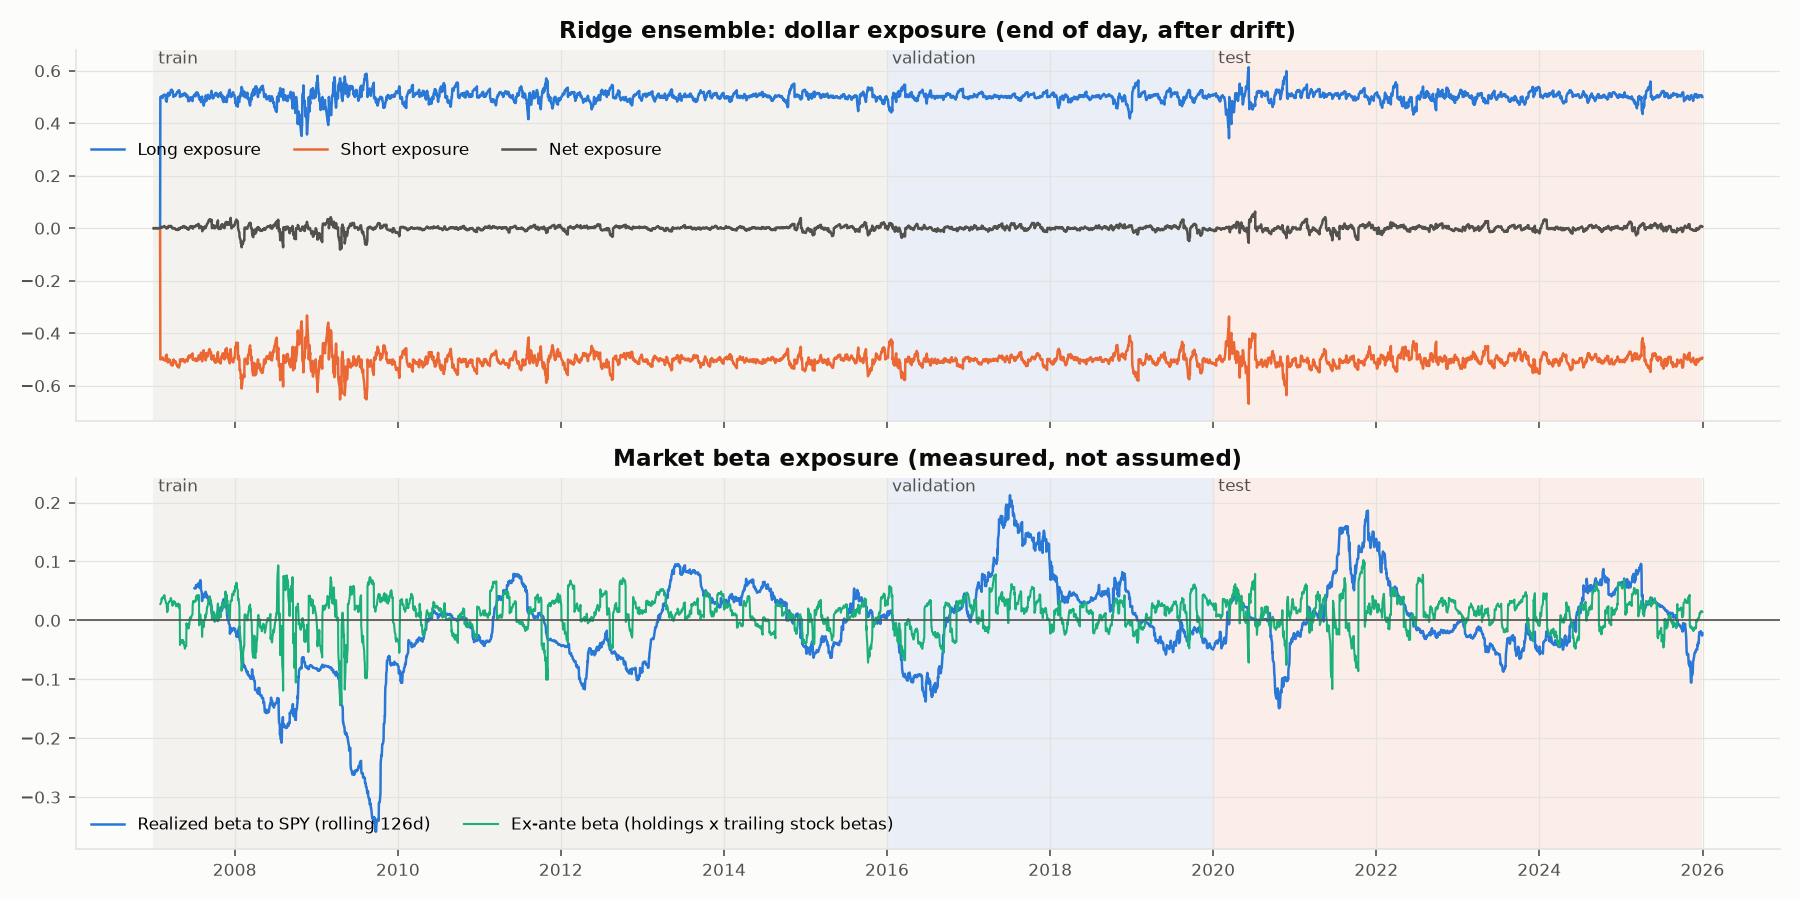

In [10]:
fig("market_beta_exposure")

## Figures

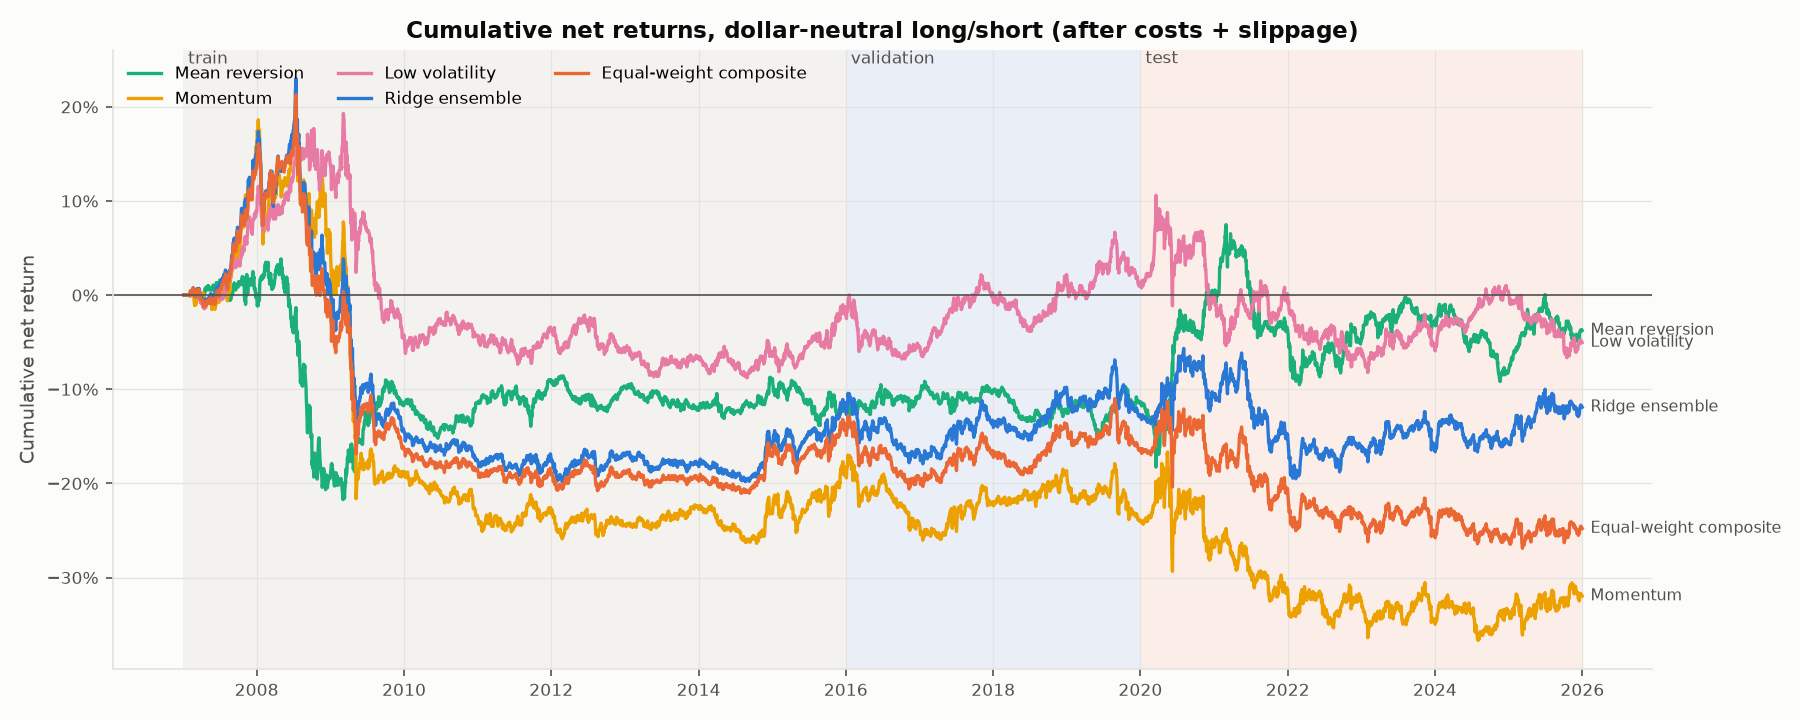

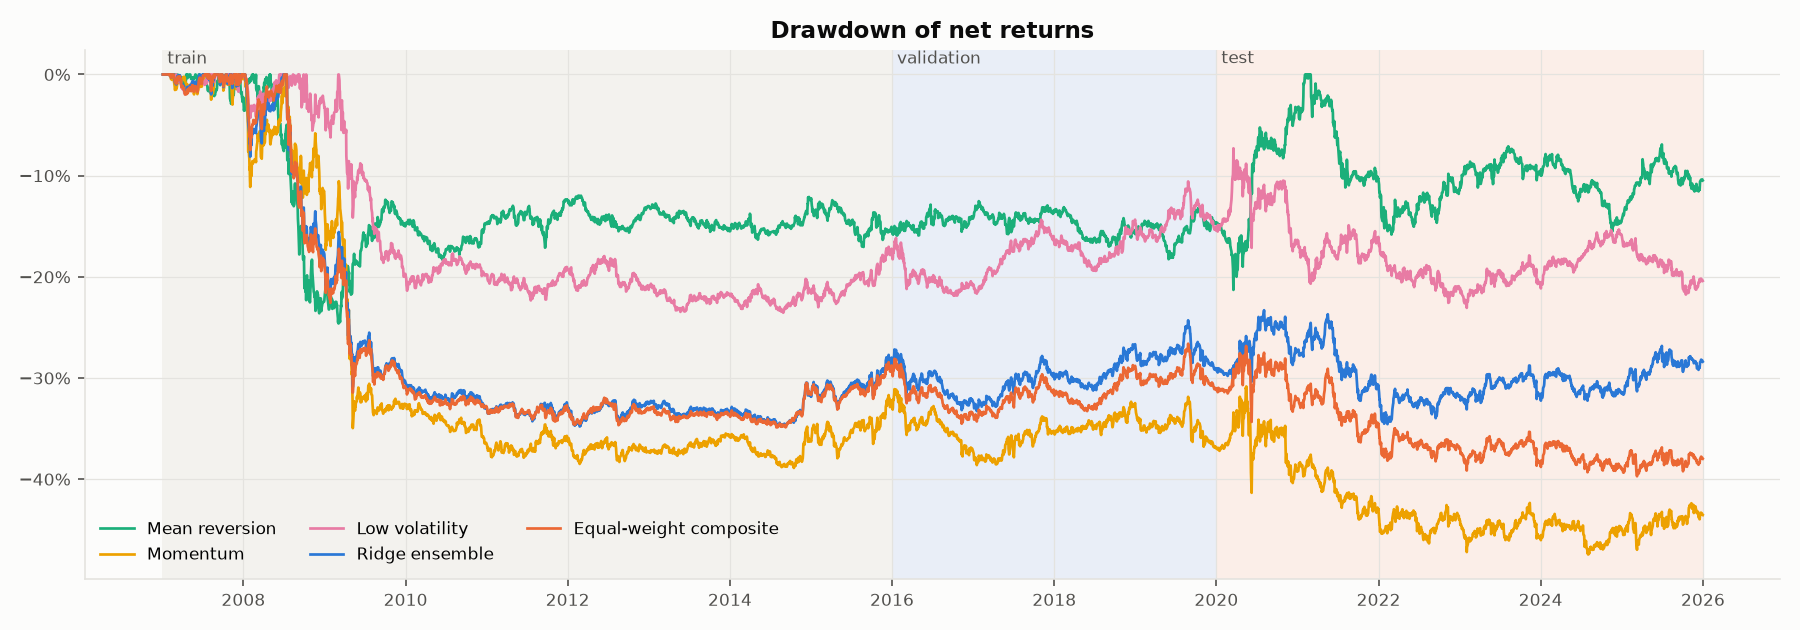

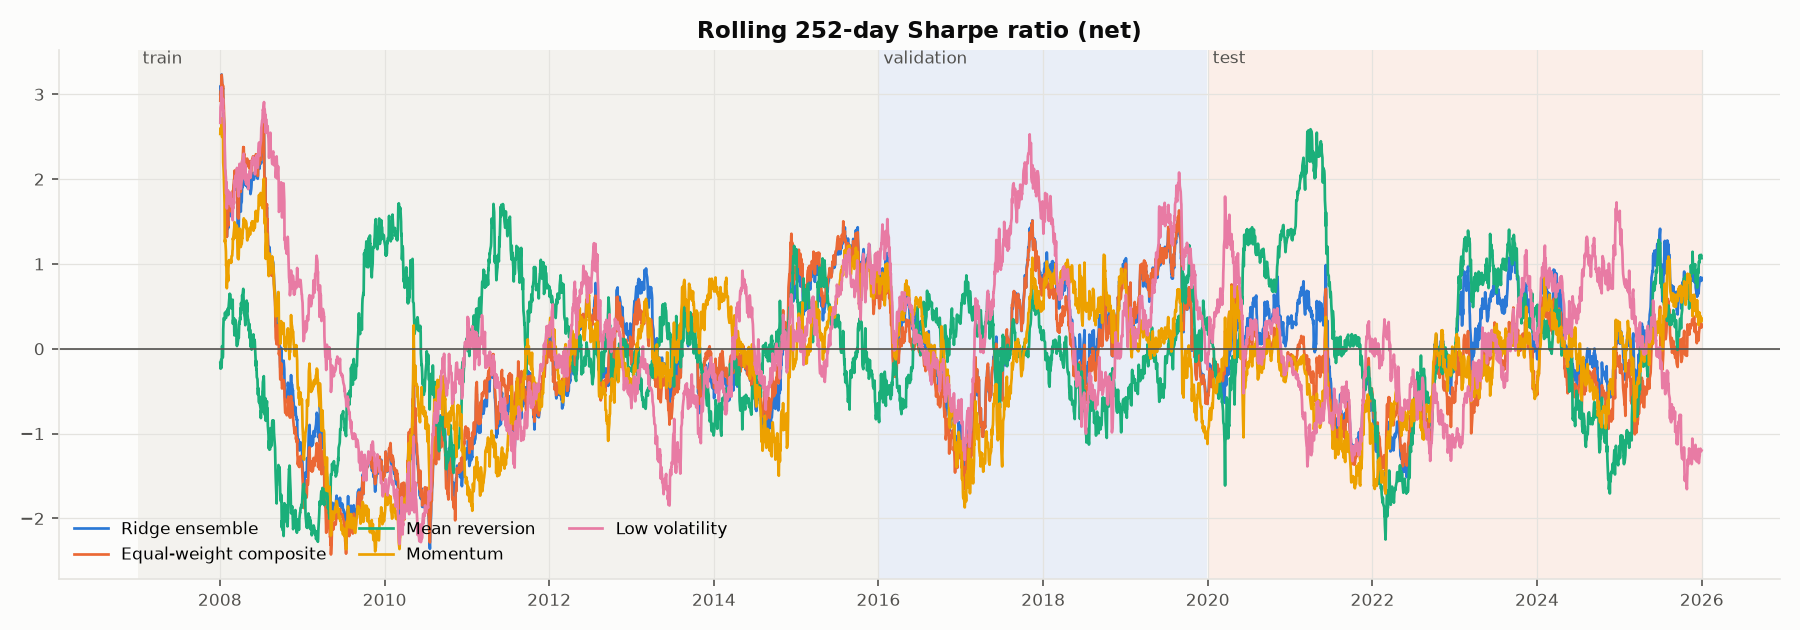

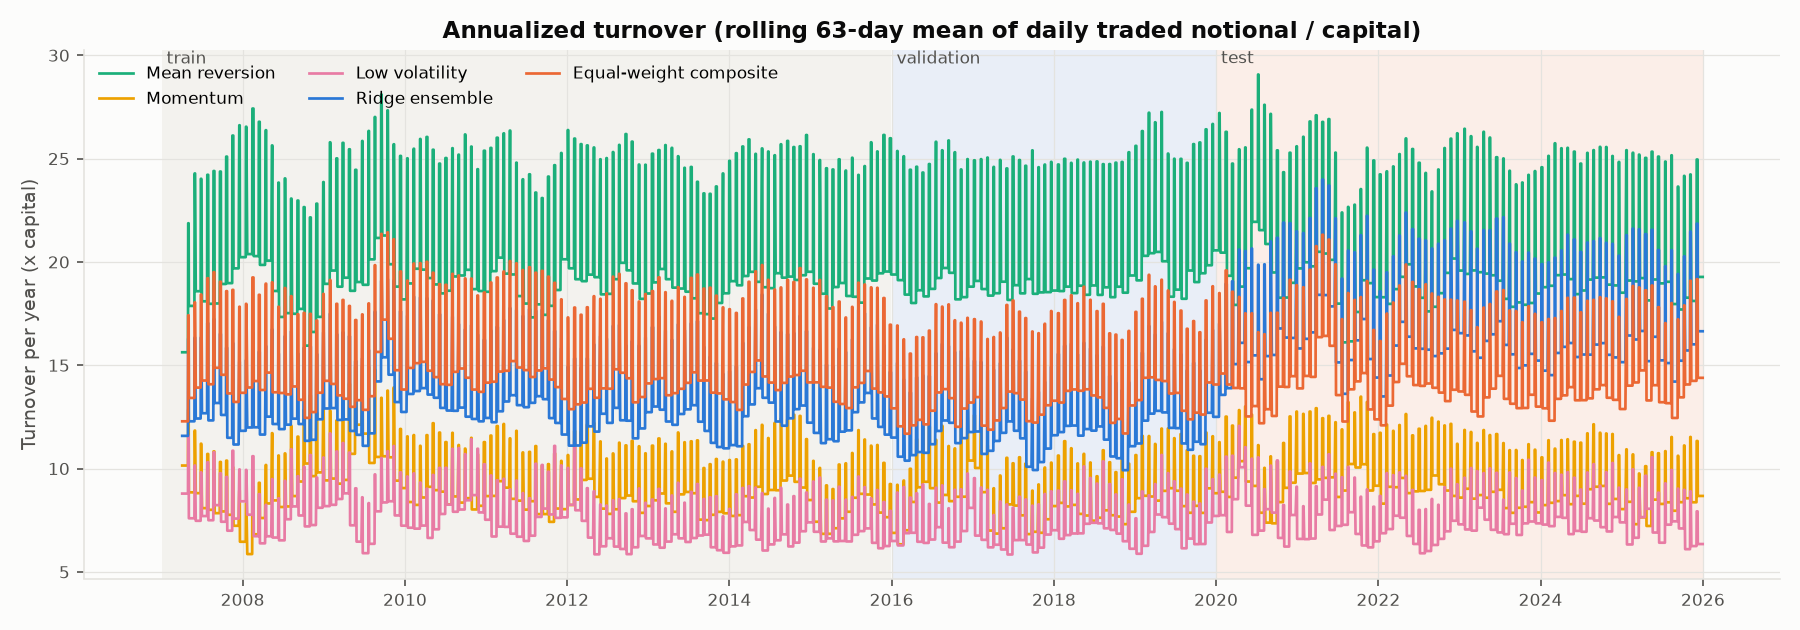

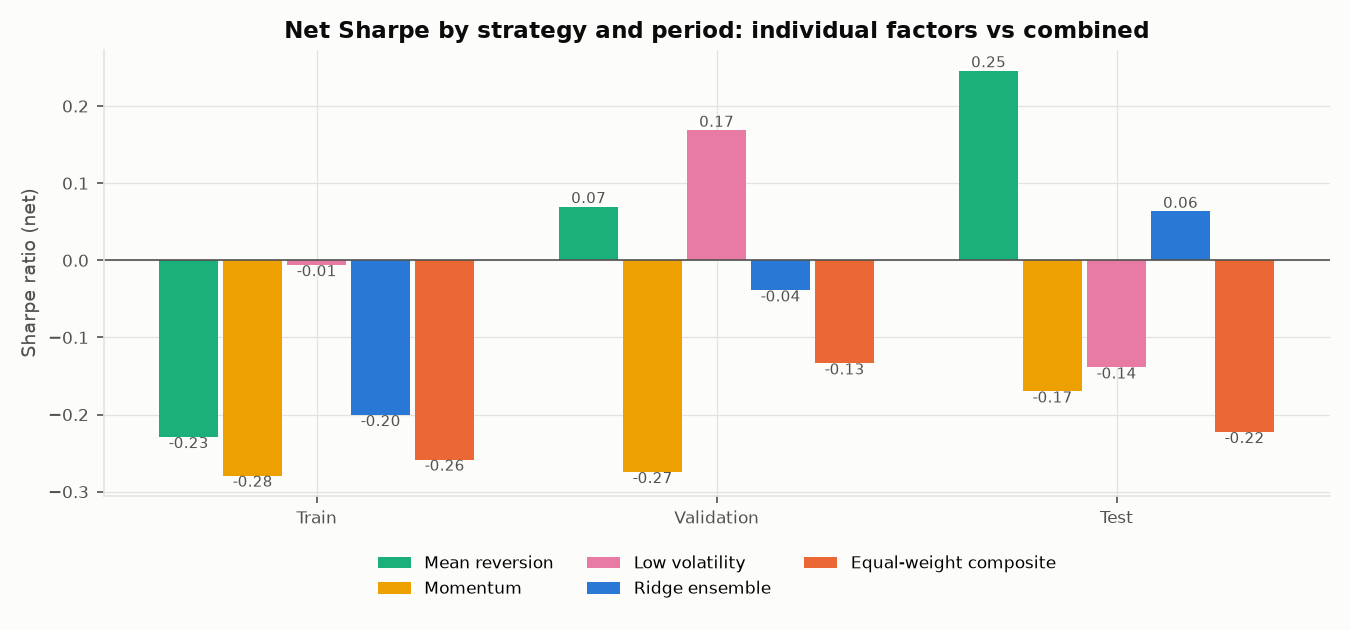

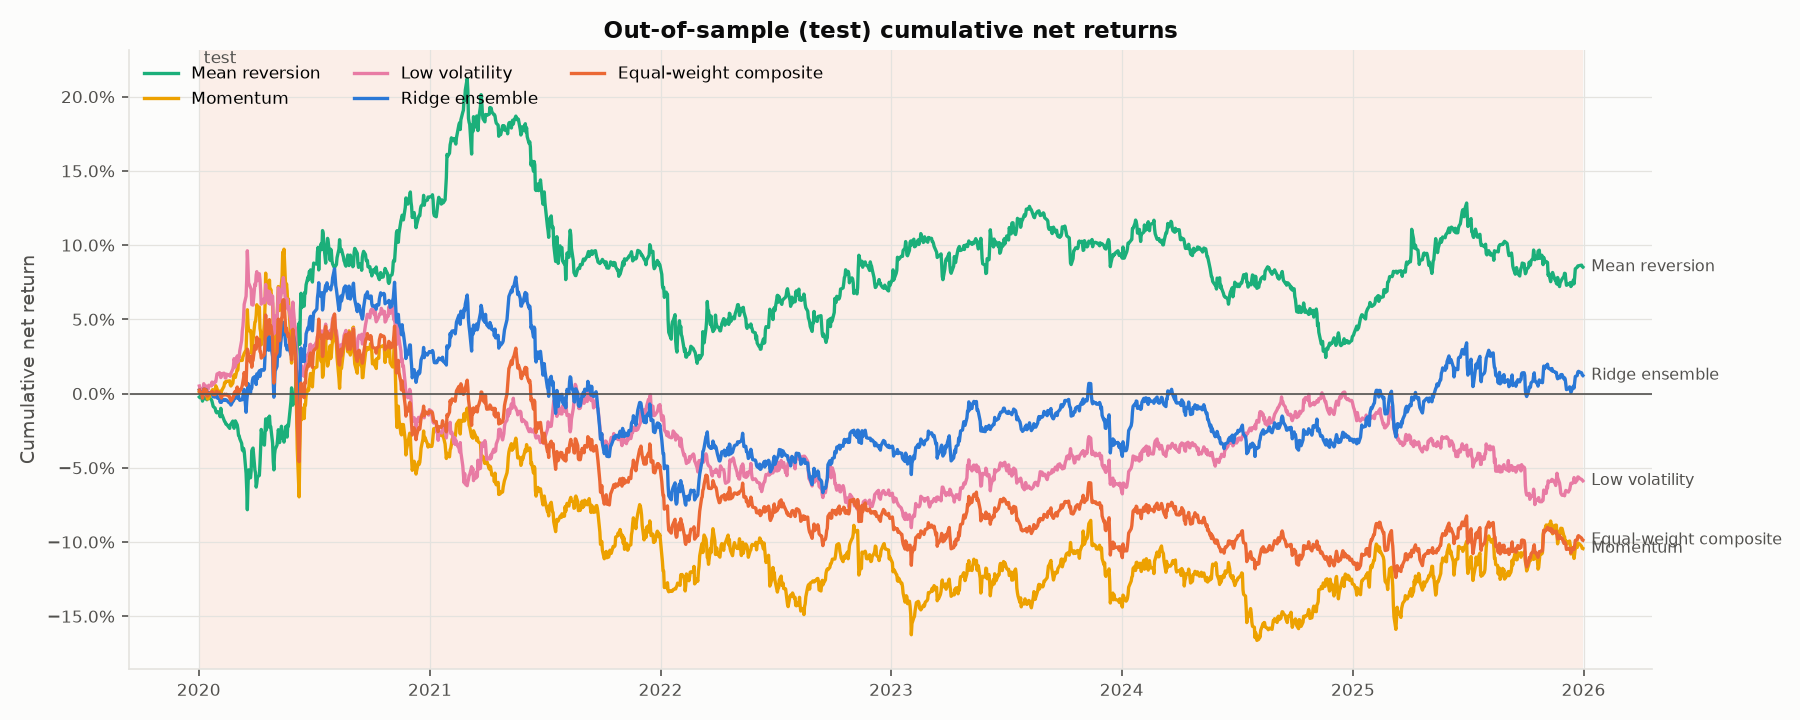

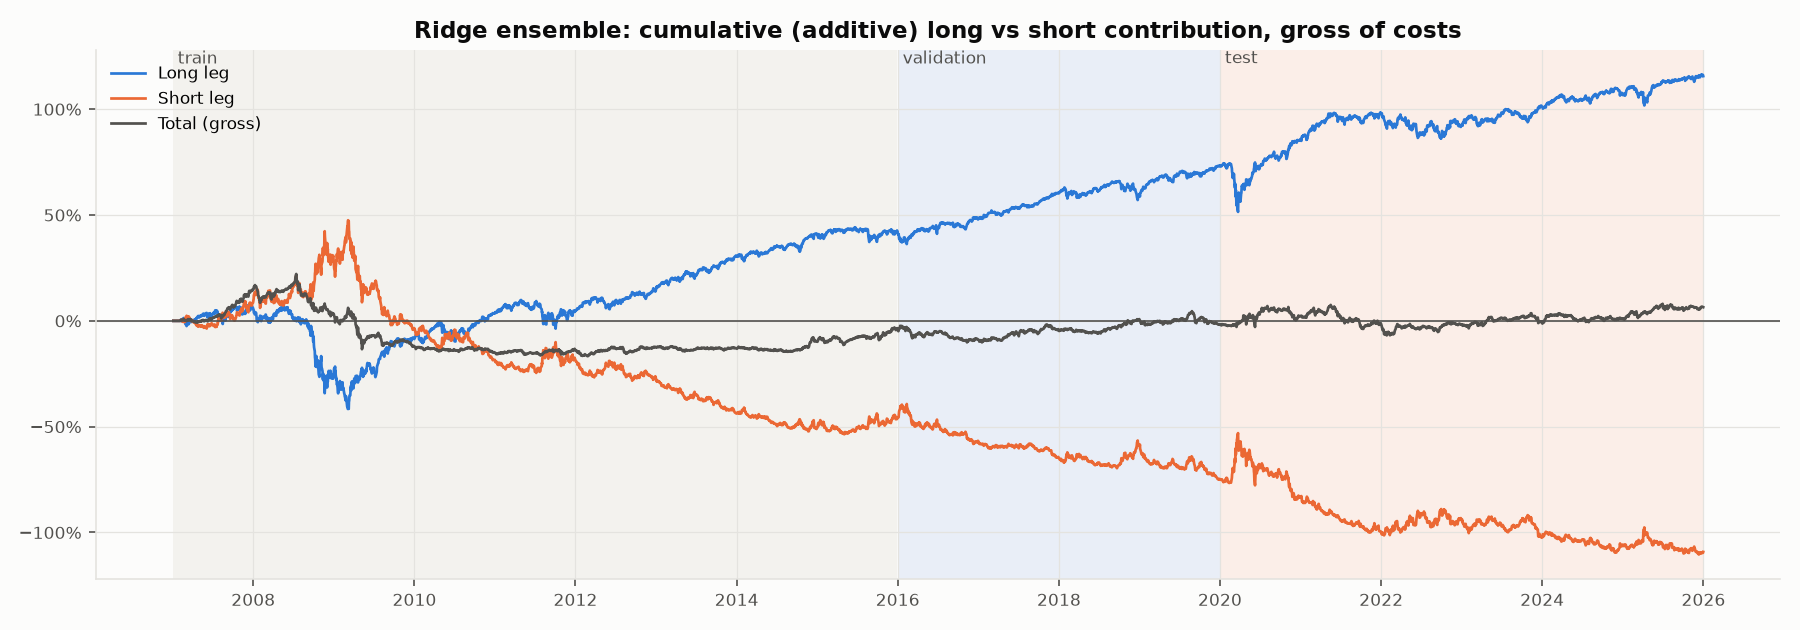

In [11]:
for f in ["cumulative_returns", "drawdown_underwater", "rolling_sharpe", "portfolio_turnover",
          "strategy_comparison", "out_of_sample_returns", "long_short_contribution"]:
    fig(f)

## Sensitivity

In [12]:
table("cost_sensitivity_validation_sharpe", index_col=0)

,reversal,momentum,volatility,ensemble,equal_weight
total_bps,,,,,
0,0.3784,-0.1830,0.2649,0.1069,0.0408
5,0.1210,-0.2591,0.1847,-0.0147,-0.1045
10,-0.1340,-0.3351,0.1045,-0.1358,-0.2491
20,-0.6225,-0.4860,-0.0554,-0.3752,-0.5332
40,-1.4497,-0.7809,-0.3699,-0.8328,-1.0652


In [13]:
table("cost_sensitivity_test_sharpe", index_col=0)

,reversal,momentum,volatility,ensemble,equal_weight
total_bps,,,,,
0,0.4324,-0.1065,-0.0643,0.2213,-0.0962
5,0.2769,-0.1594,-0.1264,0.0898,-0.2015
10,0.1217,-0.2122,-0.1884,-0.0414,-0.3064
20,-0.1845,-0.3177,-0.3122,-0.3009,-0.5145
40,-0.7603,-0.5270,-0.5570,-0.7955,-0.9159


In [14]:
table("execution_lag_sensitivity_ensemble", index_col=0)

,train,validation,test
execution_lag,,,
0,-0.1932,-0.0555,0.1610
1,-0.2005,-0.0389,0.0635
2,-0.2101,-0.0486,0.0634


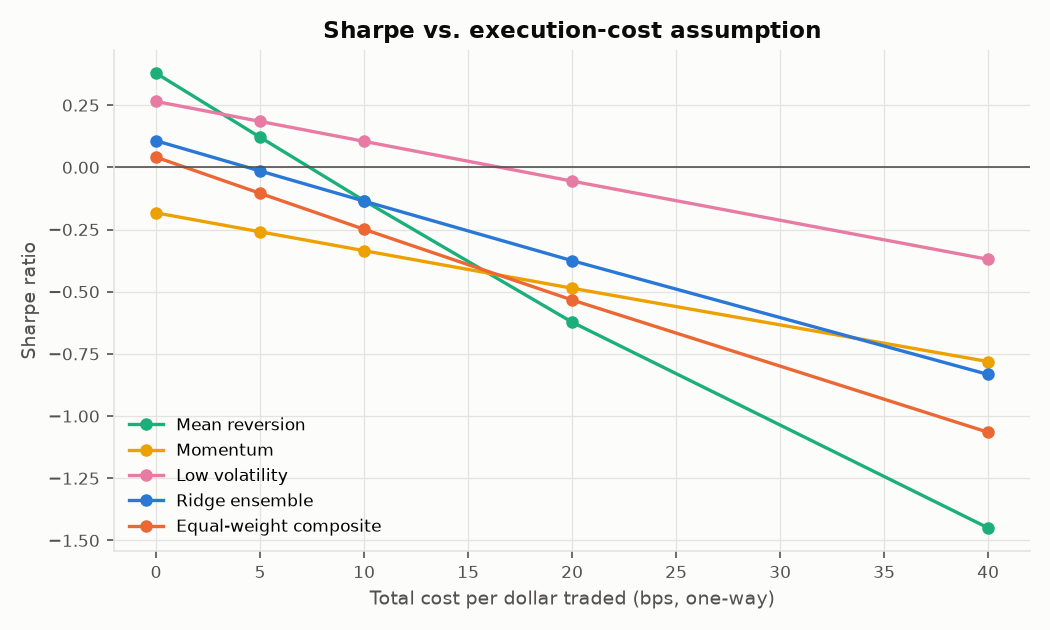

In [15]:
fig("cost_sensitivity_validation", 800)